# K Shortest Simple Paths (KSSP) — Algorithm Comparison
## Yen's Algorithm with A* Search  vs  Dynamic Programming

**Reference:** Al-Zoobi, Coudert, Nisse — Space and time trade-off for the k shortest simple paths problem* (2020)

**Mission:** Find the k shortest simple paths between 2 nodes in a graph where **no node is visited twice**!

## Cell 1 — Imports

In [ ]:
import heapq #min-heap used by A* and Yen's candidate queue
import math
import time
import random
import copy #snapshot graph before mutating it
import statistics
from collections import defaultdict #self intializes adjacency list

import numpy as np

#visualisation libs
import matplotlib.pyplot as plt
import networkx as nx #graph visualization

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
COLORS = {"Yen's + A*": "#1f77b4", "DP enumeration": "#ff7f0e"}
print("Imports OK.")

Imports OK.


##Graph Class & Utilities
 A directed graph stored as an adjacency list where
 **direction matters!**
 - A --> B != B --> A

###Benchmarking
1. Vary k
2. Scale n
3. OPS Counters

In [ ]:
class WeightedDiGraph:
    def __init__(self):
        self.graph = defaultdict(list)
        self.positions = {}
        # distance estimate

    # add connection from node u to node v with cost w
    def add_edge(self, u, v, w):
        self.graph[u].append((v, w))

    def add_position(self, node, x, y):
        """Stores 2-D coordinate for Euclidean heuristic (coordinates of nodes)
        for Eucledean distance calculations and A* heuristic estimation.
        If positions are not set, heuristic falls back to 0 (Dijkstra behaviour).
        """
        self.positions[node] = (x, y)

    def nodes(self):
        result = set(self.graph.keys())
        for u in self.graph:
            for v, _ in self.graph[u]:
                result.add(v)
        return result

    def neighbours(self, u):
        return self.graph[u]

    def node_count(self):
        return len(self.nodes())

    def edge_count(self):
        return sum(len(v) for v in self.graph.values())


def path_cost(graph, path):
    """Traverses consecutive pair of nodes at each depth level and sums their edge costs.
    Returns ∞ if edge is missing.
    Always called with the clean `original` copy NOT the mutated `working` copy.
    """
    total = 0 #initialize sum
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        for nxt, w in graph.neighbours(u):
            if nxt == v:
                total += w
                break
        else:
            return math.inf
    return total

#shared counter dictionary for implemented solutions
# counter increments when:
# 1. A* pops a node from the heap
# OR
# 2. DP pops from its stack
OPS = {"yen_expansions": 0, "dp_expansions": 0, "dp_paths_enumerated": 0}

#measures heap pops and stack pops directly (independent of CPU spped)
def reset_ops():
    for k in OPS:
        OPS[k] = 0

# runs a function several times & returns mean & standard deviation of wall-clock time
# (measures total time to execute a program in a computer aka program runtime)
# evaluates how an algorithm or system performs as the size of its input (or its overall complexity) increases
def timed(fn, repeats=3):
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    mean = statistics.mean(times)
    std  = statistics.stdev(times) if len(times) > 1 else 0.0
    return mean, std


print("Graph class and utilities loaded.")

Graph class and utilities loaded.


##Algorithm 1: Yen's + A*

In [ ]:
def euclidean_heuristic(graph):
    """
    - returns a function 'h(u, goal)' that computes straight-line distance between 2 nodes using their stored (x,y) positions
    (how far is this node from the goal?)
    - returns 0 if no positions are stored (Dijkstra fallback)
    GOOD HEURISTIC is admissible (never oversestimate actual cost) and stays mathematically consistent
    """
    def h(u, goal):
        pos = graph.positions
        if u in pos and goal in pos:
            x1, y1 = pos[u]
            x2, y2 = pos[goal]
            return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
        return 0   # graceful fallback — Dijkstra behaviour
    return h


#finds cheapest simple path from start to goal in modified graph
def astar(graph, start, goal, heuristic):
    h0 = heuristic(start, goal)
    # heap: (f_value, g_cost, node, path_as_tuple)
    # g: current actual cost to reach node
    # f (estimated total cost) = g (edge cost) + h (heuristic)
    # path_tuple: nodes visited so far (immutable)
    pq = [(h0, 0, start, (start,))]
    best_g = {start: 0}

    while pq:
        f, g, node, path_tuple = heapq.heappop(pq) #priority queue
        # ^ 1. pop entry with smallest f
        # 2. check if arrived at goal
        # 3. if not expand neighbours
        # - neighbour is skipped if already in path_tuple
        #   * simplicity guard for NO REPEATED VERTICES
        OPS["yen_expansions"] += 1

        if node == goal:
            return g, list(path_tuple)

        # ensures updated lower g paths are added while older entries are removed
        if g > best_g.get(node, math.inf):
            continue

        #simplicity guard: check neighbour in path_tuple before expanding
        for neighbour, weight in graph.neighbours(node):
            if neighbour in path_tuple:        # ref paper: vi != vj for all i < j
                continue

            new_g = g + weight
            if new_g < best_g.get(neighbour, math.inf):
                best_g[neighbour] = new_g
                new_f = new_g + heuristic(neighbour, goal)
                heapq.heappush(pq, (new_f, new_g, neighbour, path_tuple + (neighbour,)))

    return math.inf, []


#outer loop calls astar function repeatedly to build k paths
# 1. Yen's outer framework modifies graph into what paper describes as subgraph Di(Q)
# - certain nodes & edges are removed
# 2. Modified graph is then passed in to a_star function
def yen_astar(graph, start, goal, k, heuristic=None):
    """
    Returns: [(cost, path), ...] sorted by increasing cost, length k
    """
    if heuristic is None:
        heuristic = euclidean_heuristic(graph)

    working  = copy.deepcopy(graph) # mutable version of graph
    # ^ edges and sometimes nodes are temporarily removed from this graph
    #   when looking for spur paths (deviations from previous shortest paths)
    # - working graph is meticulously restored to its state before the modifications for next iteration is made
    original = copy.deepcopy(graph)
    # ^ accurately calculate path_cost, ensures that path_cost computed is based on the true, unaltered edge weights

    first_cost, first_path = astar(working, start, goal, heuristic)
    if not first_path:
        return []

    # deviation_index=0 for initial path — it deviates at position 0
    A = [(first_cost, 0, first_path)]   # confirmed k-shortest paths
    B = []                              # candidate min-heap (paths that might be next)
    #1. generate new candidates into B in every iteration
    #2. promote lowest path_cost path into A

    # Key = (spur_node, next_node_in_spur) — mirrors ref paper's prefix + arc logic
    seen_prefix_keys = set()

    for _ in range(1, k):
        _, _, previous_path = A[-1]

        #candidates generated at below code
        for i in range(len(previous_path) - 1):
            #deviation point
            spur_node = previous_path[i]
            #prefix shared with previous path
            root_path = previous_path[:i + 1]
            # for each node i (deviation index) in last confirmed path, try a different path from that node
            # - the prefix before i stays the same
            # - the path after node i deviates (force a diff turn)
            # *guarantees no alternative is missed

            # remove arc vivi+1 for every confirmed path sharing this root
            # ref paper: "remove arc vivi+1 to ensure computed path is a new one"
            removed_edges = []
            for _, _, p in A:
                if len(p) > i and p[:i + 1] == root_path:
                    # remove edge u->v from working graph
                    u, v = p[i], p[i + 1]
                    for edge in list(working.graph[u]):
                        if edge[0] == v:
                            # below removals ensures A* does not take the same path again (no revisting of nodes!)
                            # remove nest edge to force a diff turn
                            working.graph[u].remove(edge)
                            # remove prefix nodes to prevent looping back to root
                            removed_edges.append((u, edge))

            # remove v0,...,vi-1 to prevent non-simple extensions
            # ref paper: "remove vertices v0,...,vi-1 to avoid non simple extension"
            # emptying adjacency list = remove nodes in root path
            # - simplicity guard: prevent nodes from appearing in spur path
            removed_node_edges = []
            for root_node in root_path[:-1]:
                if root_node in working.graph:
                    removed_node_edges.append((root_node, working.graph[root_node]))
                    working.graph[root_node] = []

            #run A* on modified subgraph Di(Q)
            spur_cost, spur_path = astar(working, spur_node, goal, heuristic)

            if spur_path:
                total_path = root_path[:-1] + spur_path
                # root prefix (up to but not including spur node) joined with new spur segment
                # recompute cost against clean original (prevnts bugs caused by mutation of original list)
                total_cost = path_cost(original, total_path)

                if len(spur_path) > 1:
                    prefix_key = (spur_node, spur_path[1])
                else:
                    prefix_key = (spur_node, None)

                confirmed_paths = [p for _, _, p in A]
                if (prefix_key not in seen_prefix_keys
                        and total_path not in confirmed_paths):
                    seen_prefix_keys.add(prefix_key)

                    #add potential next paths into B including deviation index i
                    heapq.heappush(B, (total_cost, i, total_path))

            #restore graph after each spur by putting back every removed edge & node
            #so that next iteration of inner loop can try diff spur point on same graph
            for u, edge in removed_edges:
                working.graph[u].append(edge)
            for node, edges in removed_node_edges:
                working.graph[node] = edges

        if not B:
            break
        # extract best candidate from B and add it into A
        A.append(heapq.heappop(B))

    #return (cost, path) pairs — strip deviation_index for callers
    return [(c, p) for c, _, p in A]


print("Yen's + A* loaded.")

Yen's + A* loaded.


##Algorithm 2: DP Exhaustive Enumeration

It is used to test correctness of results as it lists every path independently.

In [ ]:
def dp_k_shortest_paths(graph, start, goal, k):
    results = []
    stack = [(start, [start], 0)]
    # stack stores current node, current path & accumulated cost
    while stack:
        current, path, cost = stack.pop()
        OPS["dp_expansions"] += 1
        if current == goal:
            OPS["dp_paths_enumerated"] += 1
            results.append((cost, path))
            continue
        for neighbour, weight in graph.neighbours(current):
            if neighbour not in path:   # simplicity constraint, stops infinite loops and repeated nodes
                stack.append((neighbour, path + [neighbour], cost + weight))
                #cost + weight = total path cost
    results.sort(key=lambda x: x[0])
    # ^ sort paths by lowest path_cost
    return results[:k]


print("DP enumeration loaded.")

DP enumeration loaded.


##Graph Builders (Marginal Cases)

In [ ]:
def build_demo_graph():
    """CASE 0: Demo graph A-F — no positions (heuristic = 0, Dijkstra fallback)."""
    g = WeightedDiGraph()
    for u, v, w in [
        ("A","B",1),("A","C",5),("A","D",2),
        ("B","C",2),("B","E",6),("B","D",2),
        ("C","E",2),("C","F",7),
        ("D","C",2),("D","E",5),("D","F",8),
        ("E","F",1),
    ]:
        g.add_edge(u, v, w)
    return g, "A", "F"


def build_tiny_graph():
    """CASE 1: Tiny DAG n=10 — integer nodes, no positions."""
    g = WeightedDiGraph()
    for u, v, w in [
        (0,1,2),(0,2,5),(0,3,1),(1,4,3),(2,4,1),(2,5,4),
        (3,2,3),(3,5,7),(4,5,2),(4,6,5),(5,6,1),(5,7,3),
        (6,7,2),(6,8,4),(7,8,1),(7,9,4),(8,9,1),
    ]:
        g.add_edge(u, v, w)
    return g, 0, 9


def random_dag(n, edge_prob=0.25, max_weight=10, seed=0):
    """
    Random Directed Acyclic Graph (DAG): forward-only edges (i<j) guarantee no cycles.
    Backbone guarantees at least one path exists.
    No positions --> heuristic falls back to 0.
    """
    rng = random.Random(seed)
    g = WeightedDiGraph()
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < edge_prob:
                g.add_edge(i, j, rng.randint(1, max_weight))
    for i in range(n - 1):
        if (i + 1) not in {v for v, _ in g.neighbours(i)}:
            g.add_edge(i, i + 1, rng.randint(1, max_weight))
    return g, 0, n - 1


def build_dag_grid(rows, cols, seed=42):
    """
    DAG grid — right and down edges only (no cycles).
    NEW: node positions stored so A* uses real Euclidean heuristic.
    Positions: node r*cols+c is at coordinate (c, r).
    WARNING: exponential simple paths — DP skipped on large grids.
    """
    g = WeightedDiGraph()
    rng = random.Random(seed)
    for r in range(rows):
        for c in range(cols):
            node = r * cols + c
            g.add_position(node, c, r)
            if c + 1 < cols:
                g.add_edge(node, node + 1, rng.randint(1, 10))
            if r + 1 < rows:
                g.add_edge(node, node + cols, rng.randint(1, 10))
    return g, 0, rows * cols - 1


def build_cyclic_graph():
    """CASE 10: Cyclic graph — key marginal case showing Yen's handles cycles, DP cannot.
    Cycle: 1->2->3->1.  Yen's A* simplicity guard prevents infinite loops.
    """
    g = WeightedDiGraph()
    for u, v, w in [(0,1,1),(1,2,2),(2,3,1),(3,1,1),(3,4,2),(4,5,1)]:
        g.add_edge(u, v, w)
    return g, 0, 5


def build_disconnected_graph():
    """CASE 11: Disconnected — no path from 0 to 9. Both algorithms return [] gracefully."""
    g = WeightedDiGraph()
    for i in range(4):
        g.add_edge(i, i + 1, 1)
    for i in range(5, 9):
        g.add_edge(i, i + 1, 1)
    return g, 0, 9


print("Graph builders loaded.")

Graph builders loaded.


## Testing Correctness of Yen's using DP

In [ ]:
g, s, t = build_demo_graph()
k = 5

r_yen = yen_astar(copy.deepcopy(g), s, t, k)
r_dp  = dp_k_shortest_paths(copy.deepcopy(g), s, t, k)

print(f"=== Demo graph correctness check, k={k} ===")
print(f"{'#':<4} {'Yen cost':>9} {'Yen path':<35} {'DP cost':>8} {'DP path'}")
print("-" * 85)
for i in range(max(len(r_yen), len(r_dp))):
    yc, yp = r_yen[i] if i < len(r_yen) else ("—", [])
    dc, dp_ = r_dp[i]  if i < len(r_dp)  else ("—", [])
    mark = "✓" if yc == dc else "(tie-break)"
    print(f"{i+1:<4} {str(yc):>9} {str(yp):<35} {str(dc):>8} {str(dp_)}  {mark}")

yen_costs = sorted(c for c, _ in r_yen)
dp_costs  = sorted(c for c, _ in r_dp)
print(f"\nYen costs: {yen_costs}")
print(f"DP costs:  {dp_costs}")
print(f"Cost sequences match: {yen_costs == dp_costs}")

# Verify all paths are simple
all_simple_yen = all(len(p) == len(set(p)) for _, p in r_yen)
all_simple_dp  = all(len(p) == len(set(p)) for _, p in r_dp)
print(f"All Yen paths simple: {all_simple_yen}")
print(f"All DP paths simple:  {all_simple_dp}")

=== Demo graph correctness check, k=5 ===
#     Yen cost Yen path                             DP cost DP path
-------------------------------------------------------------------------------------
1            6 ['A', 'B', 'C', 'E', 'F']                  6 ['A', 'B', 'C', 'E', 'F']  ✓
2            7 ['A', 'D', 'C', 'E', 'F']                  7 ['A', 'D', 'C', 'E', 'F']  ✓
3            8 ['A', 'C', 'E', 'F']                       8 ['A', 'D', 'E', 'F']  ✓
4            8 ['A', 'B', 'E', 'F']                       8 ['A', 'C', 'E', 'F']  ✓
5            8 ['A', 'B', 'D', 'C', 'E', 'F']             8 ['A', 'B', 'D', 'C', 'E', 'F']  ✓

Yen costs: [6, 7, 8, 8, 8]
DP costs:  [6, 7, 8, 8, 8]
Cost sequences match: True
All Yen paths simple: True
All DP paths simple:  True


##Heuristic Demonstration:
###A* with heuristic VS A* with h = 0

In [ ]:
# Compare expansions: zero heuristic vs Euclidean heuristic on 5x5 grid
g_grid, s_g, t_g = build_dag_grid(5, 5)

# With zero heuristic (original behaviour — Dijkstra)
def zero_h(u, goal): return 0
reset_ops()
r_zero = yen_astar(copy.deepcopy(g_grid), s_g, t_g, k=3, heuristic=zero_h)
exp_zero = OPS["yen_expansions"]

# With real Euclidean heuristic (fixed behaviour)
reset_ops()
r_euclid = yen_astar(copy.deepcopy(g_grid), s_g, t_g, k=3)
exp_euclid = OPS["yen_expansions"]

print("=== Heuristic comparison on 5x5 grid, k=3 ===")
print(f"  h=0 (Dijkstra):          {exp_zero:>6} A* node expansions")
print(f"  h=Euclidean (fixed A*):  {exp_euclid:>6} A* node expansions")
if exp_zero > 0:
    reduction = (1 - exp_euclid/exp_zero) * 100
    print(f"  Reduction: {reduction:.1f}% fewer expansions with real heuristic")
print(f"\n  Both find same paths: {sorted(c for c,_ in r_zero) == sorted(c for c,_ in r_euclid)}")

=== Heuristic comparison on 5x5 grid, k=3 ===
  h=0 (Dijkstra):             162 A* node expansions
  h=Euclidean (fixed A*):     157 A* node expansions
  Reduction: 3.1% fewer expansions with real heuristic

  Both find same paths: True


##Path Visualizations

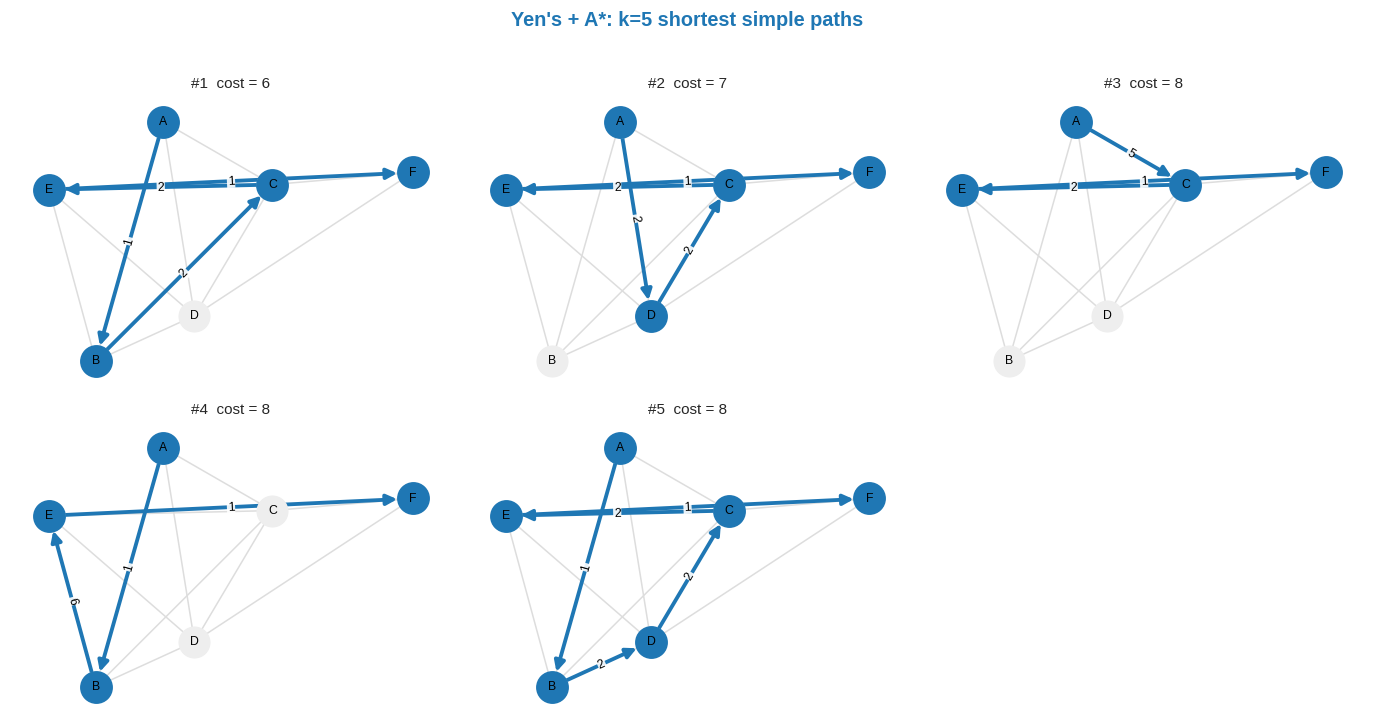

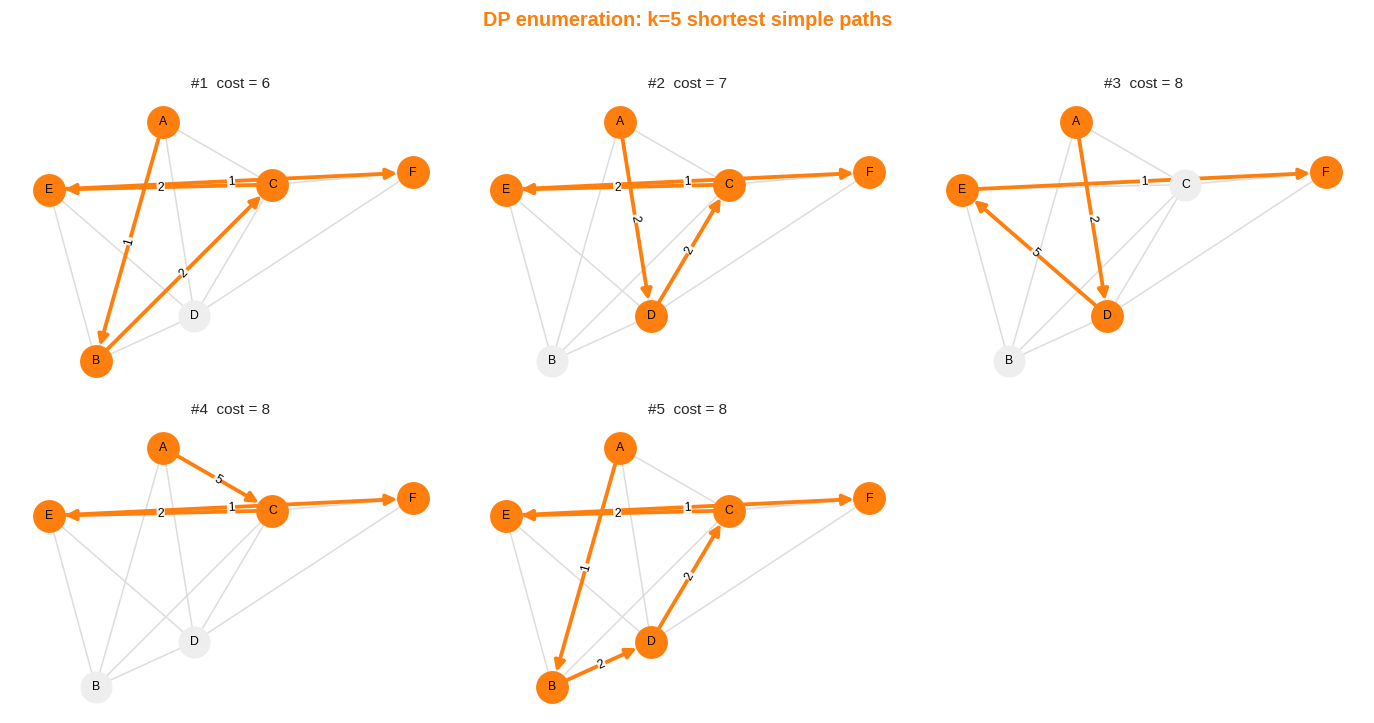

In [ ]:
def draw_k_paths(g_nx, pos, paths, title, color, ncols=3):
    # It takes a graph, node positions, a list of paths, a title, and a color to draw them.
    if not paths:
        print(f"{title}: no paths")
        return
    # We calculate how many rows and columns of plots we need.
    nrows = (len(paths) + ncols - 1) // ncols
    # Create a figure and a set of subplots for each path.
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows))
    # Make sure `axes` is always a flat list, even if there's only one plot.
    axes = [axes] if (nrows == 1 and ncols == 1) else list(np.array(axes).flatten())

    # Loop through each path to draw it.
    for idx, (cost, path) in enumerate(paths):
        ax = axes[idx] # Get the specific subplot for this path.
        path_edges = list(zip(path[:-1], path[1:])) # Get all the (node, next_node) pairs in this path.

        # Draw all nodes and edges in the graph in a light color first.
        nx.draw_networkx_nodes(g_nx, pos, node_color="#eeeeee", node_size=400, ax=ax)
        nx.draw_networkx_edges(g_nx, pos, edge_color="#dddddd", arrows=False, ax=ax)

        # Then, highlight the nodes and edges that are part of the *current* path.
        nx.draw_networkx_nodes(g_nx, pos, nodelist=path, node_color=color, node_size=420, ax=ax)
        # Add labels to the nodes.
        nx.draw_networkx_labels(g_nx, pos, font_size=8, ax=ax)
        nx.draw_networkx_edges(g_nx, pos, edgelist=path_edges, edge_color=color,
                               width=2.5, arrows=True, arrowsize=14, node_size=420, ax=ax)
        # Add edge weights (costs) as labels on the highlighted path edges.
        ew = {(u, v): g_nx[u][v]["weight"] for u, v in path_edges if g_nx.has_edge(u, v)}
        nx.draw_networkx_edge_labels(g_nx, pos, edge_labels=ew, font_size=8,
                                     bbox=dict(facecolor="white", edgecolor="none", alpha=0.9, pad=0.5), ax=ax)
        # Set the title for each individual subplot (e.g., "#1 cost = 6").
        ax.set_title(f"#{idx+1}  cost = {cost}", fontsize=10)
        ax.axis("off") # Hide the axis frame for a cleaner graph visualization.

    # If there are more subplots than paths (e.g., ncols is larger than path count),
    # turn off the unused subplots.
    for j in range(len(paths), len(axes)):
        axes[j].axis("off")

    # Add a main title for the entire figure.
    fig.suptitle(title, fontsize=13, color=color, y=1.02, fontweight="bold")
    plt.tight_layout() # Adjust layout to prevent labels from overlapping.
    plt.show() # Display the plots!


# Build the demo graph and convert it to a NetworkX graph format for drawing.
g_demo, s, t = build_demo_graph()
G_nx = nx.DiGraph()
for u in g_demo.graph:
    for v, w in g_demo.neighbours(u):
        G_nx.add_edge(u, v, weight=w)
pos = nx.spring_layout(G_nx, seed=7) # Arrange the nodes nicely for visualization.

# Run both Yen's and DP algorithms to get paths for the demo graph.
r_yen = yen_astar(copy.deepcopy(g_demo), s, t, 5)
r_dp  = dp_k_shortest_paths(copy.deepcopy(g_demo), s, t, 5)

# Draw the paths found by Yen's algorithm.
draw_k_paths(G_nx, pos, r_yen, "Yen's + A*: k=5 shortest simple paths",    COLORS["Yen's + A*"])
# Draw the paths found by the DP enumeration algorithm.
draw_k_paths(G_nx, pos, r_dp,  "DP enumeration: k=5 shortest simple paths", COLORS["DP enumeration"])

##Runtime Comparison for Marginal Cases

All marginal cases use the **same graph instances** so runtimes are directly comparable.
DP is capped at 2s because grid graphs have exponentially many simple paths while
Yen's + A* runtime has no cap.

In [ ]:
DP_CAP = 2.0

CASES = [
    ("0",  "Demo graph (A-F)",        lambda: build_demo_graph(),           5,  True),
    ("1",  "Tiny DAG n=10",           lambda: build_tiny_graph(),           5,  True),
    ("2",  "Random DAG n=10 p=0.25",  lambda: random_dag(10, 0.25, seed=1), 5, True),
    ("3",  "Random DAG n=15 p=0.25",  lambda: random_dag(15, 0.25, seed=2), 5, True),
    ("4",  "Random DAG n=20 p=0.25",  lambda: random_dag(20, 0.25, seed=3), 5, True),
    ("5",  "Random DAG n=25 p=0.25",  lambda: random_dag(25, 0.25, seed=4), 3, True),
    ("6",  "Random DAG n=30 p=0.25",  lambda: random_dag(30, 0.25, seed=5), 3, True),
    ("7",  "Sparse DAG n=20 p=0.15",  lambda: random_dag(20, 0.15, seed=6), 5, True),
    ("8",  "Dense DAG n=20 p=0.60",   lambda: random_dag(20, 0.60, seed=7), 5, True),
    ("9a", "Grid 5x5 (Yen only)",     lambda: build_dag_grid(5, 5),         5, False),
    ("9b", "Grid 10x10 (Yen only)",   lambda: build_dag_grid(10, 10),       5, False),
    ("10", "Cyclic n=6",              lambda: build_cyclic_graph(),          5, True),
    ("11", "Disconnected n=10",       lambda: build_disconnected_graph(),    5, True),
]

comparison_table = []
dp_skip = False

print(f"{'Case':<5} {'Graph':<26} {'n':>5} {'m':>6} {'k':>4}  "
      f"{'Yen time(s)':>12} {'Yen paths':>10}  {'DP time(s)':>11} {'DP paths':>9}")
print("-" * 95)

for case_id, name, builder, k, run_dp in CASES:
    g_orig, s, t = builder()
    n = g_orig.node_count()
    m = g_orig.edge_count()

    t0 = time.perf_counter()
    r_yen = yen_astar(copy.deepcopy(g_orig), s, t, k)
    t_yen = time.perf_counter() - t0

    if not run_dp or dp_skip:
        t_dp, r_dp = None, []
        dp_label = "skipped"
        # skip DP if it exceeds 2s of runtime on any case (prevents runaway exponential time)
    else:
        t0 = time.perf_counter()
        r_dp = dp_k_shortest_paths(copy.deepcopy(g_orig), s, t, k)
        t_dp = time.perf_counter() - t0
        dp_label = f"{t_dp:.4f}"
        if t_dp > DP_CAP:
            dp_skip = True

    print(f"{case_id:<5} {name:<26} {n:>5} {m:>6} {k:>4}  "
          f"{t_yen:>12.4f} {len(r_yen):>10}  {dp_label:>11} {len(r_dp):>9}")

    comparison_table.append({
        "case": case_id, "name": name, "n": n, "m": m, "k": k,
        "t_yen": t_yen, "paths_yen": len(r_yen),
        "t_dp": t_dp,   "paths_dp":  len(r_dp),
    })

Case  Graph                          n      m    k   Yen time(s)  Yen paths   DP time(s)  DP paths
-----------------------------------------------------------------------------------------------
0     Demo graph (A-F)               6     12    5        0.0006          5       0.0001         5
1     Tiny DAG n=10                 10     17    5        0.0007          5       0.0002         5
2     Random DAG n=10 p=0.25        10     14    5        0.0004          5       0.0001         5
3     Random DAG n=15 p=0.25        15     35    5        0.0008          5       0.0005         5
4     Random DAG n=20 p=0.25        20     55    5        0.0010          5       0.0070         5
5     Random DAG n=25 p=0.25        25     88    3        0.0017          3       0.0177         3
6     Random DAG n=30 p=0.25        30    122    3        0.0010          3       0.3063         3
7     Sparse DAG n=20 p=0.15        20     41    5        0.0008          5       0.0008         5
8     Dense D

##Varying k on Fixed Graph

In [ ]:
g_fixed, s_f, t_f = random_dag(15, edge_prob=0.35, seed=99)
K_RANGE = [1, 2, 3, 5, 8, 10, 15, 20]

print(f"Varying k — fixed DAG (n={g_fixed.node_count()}, m={g_fixed.edge_count()})")
print(f"{'k':>5} | {'Yen time(s)':>12} {'Yen paths':>10} | {'DP time(s)':>11} {'DP paths':>9}")
print("-" * 55)

yen_times_k, dp_times_k = [], []
for k_val in K_RANGE:
    t0 = time.perf_counter()
    r_y = yen_astar(copy.deepcopy(g_fixed), s_f, t_f, k_val)
    ty  = time.perf_counter() - t0

    t0 = time.perf_counter()
    r_d = dp_k_shortest_paths(copy.deepcopy(g_fixed), s_f, t_f, k_val)
    td  = time.perf_counter() - t0

    yen_times_k.append(ty)
    dp_times_k.append(td)
    print(f"{k_val:>5} | {ty:>12.4f} {len(r_y):>10} | {td:>11.4f} {len(r_d):>9}")

Varying k — fixed DAG (n=15, m=49)
    k |  Yen time(s)  Yen paths |  DP time(s)  DP paths
-------------------------------------------------------
    1 |       0.0005          1 |      0.0017         1
    2 |       0.0007          2 |      0.0012         2
    3 |       0.0006          3 |      0.0017         3
    5 |       0.0007          5 |      0.0013         5
    8 |       0.0009          8 |      0.0016         8
   10 |       0.0010         10 |      0.0011        10
   15 |       0.0013         15 |      0.0011        15
   20 |       0.0032         20 |      0.0018        20


##Scaling Benchmark (runtime vs n)

Scaling benchmark (k=5, edge_prob=0.25, 3 repeats each)
    n   Yen mean(s)    +-std   DP mean(s)    +-std
-------------------------------------------------------
    5        0.0004   0.0003       0.0001   0.0001
   10        0.0006   0.0001       0.0001   0.0000
   15        0.0007   0.0003       0.0011   0.0001
   20        0.0009   0.0002       0.0009   0.0001
   25        0.0009   0.0000       0.0341   0.0369
   30        0.0014   0.0001       0.4156   0.0358


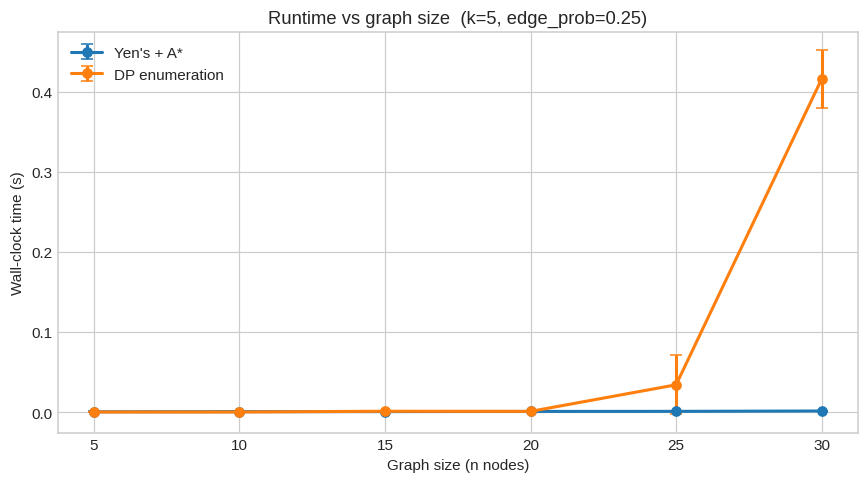

In [ ]:
ns = [5, 10, 15, 20, 25, 30]
K_BENCH = 5
REPEATS = 3

yen_means, yen_stds = [], []
dp_means,  dp_stds  = [], []
dp_wall_hit = False

print(f"Scaling benchmark (k={K_BENCH}, edge_prob=0.25, {REPEATS} repeats each)")
print(f"{'n':>5}  {'Yen mean(s)':>12} {'+-std':>8}  {'DP mean(s)':>11} {'+-std':>8}")
print("-" * 55)

for n in ns:
    g_b, s_b, t_b = random_dag(n, edge_prob=0.25, seed=n)
    ym, ys = timed(lambda: yen_astar(copy.deepcopy(g_b), s_b, t_b, K_BENCH), REPEATS)
    yen_means.append(ym); yen_stds.append(ys)

    if dp_wall_hit:
        dm, ds = float("nan"), float("nan")
        dp_str = "     (wall)         "
    else:
        dm, ds = timed(lambda: dp_k_shortest_paths(copy.deepcopy(g_b), s_b, t_b, K_BENCH), REPEATS)
        dp_str = f"{dm:>11.4f} {ds:>8.4f}"
        if dm > 2.0:
            dp_wall_hit = True
    dp_means.append(dm); dp_stds.append(ds)
    print(f"{n:>5}  {ym:>12.4f} {ys:>8.4f}  {dp_str}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.errorbar(ns, yen_means, yerr=yen_stds, marker="o",
            label="Yen's + A*", color=COLORS["Yen's + A*"], linewidth=2, capsize=4)
dp_ns   = [n for n, m in zip(ns, dp_means) if not math.isnan(m)]
dp_m_ok = [m for m in dp_means if not math.isnan(m)]
dp_s_ok = [s for s, m in zip(dp_stds, dp_means) if not math.isnan(m)]
if dp_ns:
    ax.errorbar(dp_ns, dp_m_ok, yerr=dp_s_ok, marker="o",
                label="DP enumeration", color=COLORS["DP enumeration"], linewidth=2, capsize=4)
ax.set_xlabel("Graph size (n nodes)")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Runtime vs graph size  (k={K_BENCH}, edge_prob=0.25)")
ax.legend()
plt.tight_layout()
plt.show()

## Analysis of Node Expansions

    n    Yen expansions    DP expansions   DP paths found
------------------------------------------------------------
    5                16                7                3
   10                45               41               17
   15               100              734              175
   20               146            1,074              247
   25               132           14,725            3,990
   30               185          237,027           81,047


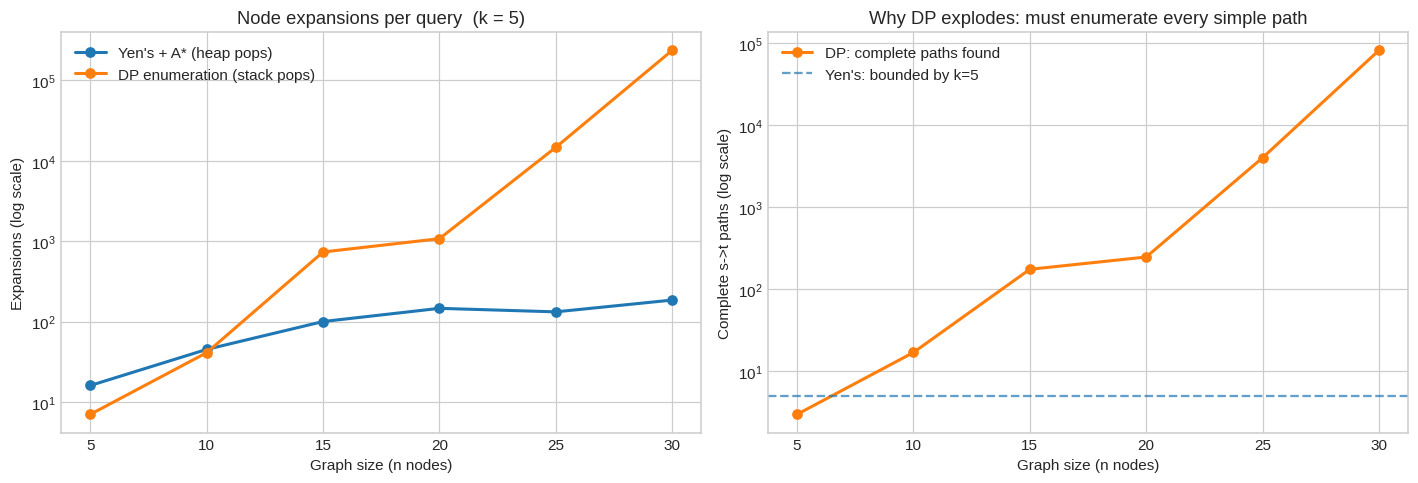

In [ ]:
ns_ops = [5, 10, 15, 20, 25, 30]
K_OPS = 5
yen_exp, dp_exp, dp_paths_enum = [], [], []

print(f"{'n':>5}  {'Yen expansions':>16}  {'DP expansions':>15}  {'DP paths found':>15}")
print("-" * 60)

for n in ns_ops:
    g_o, s_o, t_o = random_dag(n, edge_prob=0.25, seed=n)
    reset_ops()
    yen_astar(copy.deepcopy(g_o), s_o, t_o, K_OPS)
    yen_exp.append(OPS["yen_expansions"])
    reset_ops()
    dp_k_shortest_paths(copy.deepcopy(g_o), s_o, t_o, K_OPS)
    dp_exp.append(OPS["dp_expansions"])
    dp_paths_enum.append(OPS["dp_paths_enumerated"])
    print(f"{n:>5}  {yen_exp[-1]:>16,}  {dp_exp[-1]:>15,}  {dp_paths_enum[-1]:>15,}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.plot(ns_ops, yen_exp, marker="o", label="Yen's + A* (heap pops)",
         color=COLORS["Yen's + A*"], linewidth=2)
ax1.plot(ns_ops, dp_exp, marker="o", label="DP enumeration (stack pops)",
         color=COLORS["DP enumeration"], linewidth=2)
ax1.set_xlabel("Graph size (n nodes)")
ax1.set_ylabel("Expansions (log scale)")
ax1.set_title(f"Node expansions per query  (k = {K_OPS})")
ax1.set_yscale("log")
ax1.legend()

ax2.plot(ns_ops, dp_paths_enum, marker="o",
         color=COLORS["DP enumeration"], linewidth=2, label="DP: complete paths found")
ax2.axhline(K_OPS, linestyle="--", color=COLORS["Yen's + A*"], alpha=0.7,
            label=f"Yen's: bounded by k={K_OPS}")
ax2.set_xlabel("Graph size (n nodes)")
ax2.set_ylabel("Complete s->t paths (log scale)")
ax2.set_title("Why DP explodes: must enumerate every simple path")
ax2.set_yscale("log")
ax2.legend()
plt.tight_layout()
plt.show()

##Compare runtime vs k values

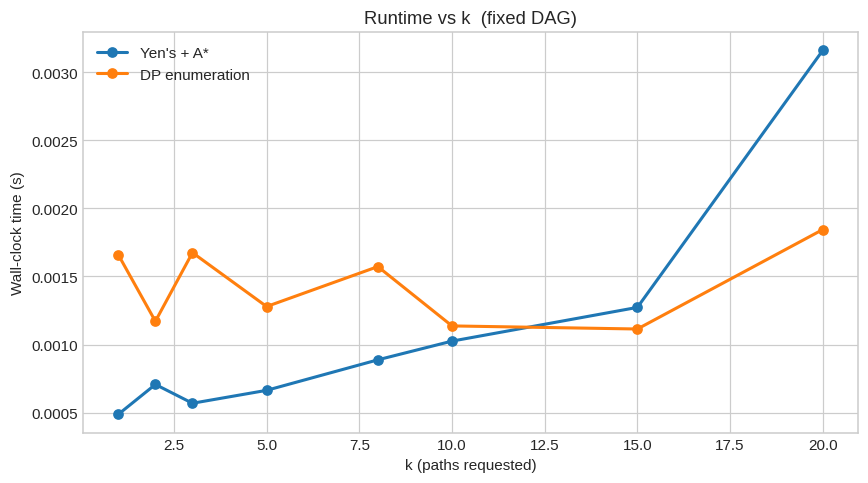

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(K_RANGE, yen_times_k, marker="o", label="Yen's + A*",
        color=COLORS["Yen's + A*"], linewidth=2)
ax.plot(K_RANGE, dp_times_k, marker="o", label="DP enumeration",
        color=COLORS["DP enumeration"], linewidth=2)
ax.set_xlabel("k (paths requested)")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title("Runtime vs k  (fixed DAG)")
ax.legend()
plt.tight_layout()
plt.show()